In [2]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving data.csv to data.csv


In [5]:
test_data = pd.read_csv('test.csv')
train_data = pd.read_csv('data.csv')

In [6]:
train_data['rating'].isnull().sum()

np.int64(0)

In [7]:
all_data = pd.concat([train_data, test_data])
n_users = all_data['user_id'].max()
n_items = all_data['item_id'].max()

print(f"\nتعداد کل کاربران: {n_users}")
print(f"تعداد کل فیلم‌ها: {n_items}")


تعداد کل کاربران: 943
تعداد کل فیلم‌ها: 1682


In [8]:
k = 5
alpha = 0.005
beta = 0.02
epochs = 50

print(f"تعداد ویژگی‌های پنهان (k): {k}")
print(f"نرخ یادگیری (alpha): {alpha}")
print(f"ضریب تنظیم (beta): {beta}")
print(f"تعداد تکرارها (epochs): {epochs}")

P = np.random.normal(loc=0, scale=0.1, size=(n_users + 1, k))
Q = np.random.normal(loc=0, scale=0.1, size=(n_items + 1, k))

print(f"\nشکل ماتریس کاربران (P): {P.shape}")
print(f"شکل ماتریس فیلم‌ها (Q): {Q.shape}")

تعداد ویژگی‌های پنهان (k): 5
نرخ یادگیری (alpha): 0.005
ضریب تنظیم (beta): 0.02
تعداد تکرارها (epochs): 50

شکل ماتریس کاربران (P): (944, 5)
شکل ماتریس فیلم‌ها (Q): (1683, 5)


In [9]:
training_history = []

print("شروع فرآیند آموزش مدل...")

for epoch in range(epochs):
  for user_id, item_id, rating, title in train_data.itertuples(index=False):
    user_vector = P[user_id]
    item_vector = Q[item_id]
    prediction = np.dot(user_vector, item_vector)

    error = rating - prediction

    P[user_id] += alpha * (error * item_vector - beta * user_vector)
    Q[item_id] += alpha * (error * user_vector - beta * item_vector)

  total_squared_error = 0

  for user_id, item_id, rating, title in train_data.itertuples(index=False):
    prediction = P[user_id] @ Q[item_id].T # ضرب داخلی
    total_squared_error += (rating - prediction)**2

  train_rmse = np.sqrt(total_squared_error / len(train_data))
  training_history.append(train_rmse)
  print(f"Epoch {epoch+1:02d}/{epochs}  |  Training RMSE: {train_rmse:.4f}")



print("\nفرآیند آموزش با موفقیت به پایان رسید!")




شروع فرآیند آموزش مدل...
Epoch 01/50  |  Training RMSE: 3.6969
Epoch 02/50  |  Training RMSE: 3.0604
Epoch 03/50  |  Training RMSE: 1.6738
Epoch 04/50  |  Training RMSE: 1.2744
Epoch 05/50  |  Training RMSE: 1.1193
Epoch 06/50  |  Training RMSE: 1.0455
Epoch 07/50  |  Training RMSE: 1.0051
Epoch 08/50  |  Training RMSE: 0.9803
Epoch 09/50  |  Training RMSE: 0.9635
Epoch 10/50  |  Training RMSE: 0.9513
Epoch 11/50  |  Training RMSE: 0.9418
Epoch 12/50  |  Training RMSE: 0.9338
Epoch 13/50  |  Training RMSE: 0.9268
Epoch 14/50  |  Training RMSE: 0.9204
Epoch 15/50  |  Training RMSE: 0.9145
Epoch 16/50  |  Training RMSE: 0.9089
Epoch 17/50  |  Training RMSE: 0.9037
Epoch 18/50  |  Training RMSE: 0.8987
Epoch 19/50  |  Training RMSE: 0.8940
Epoch 20/50  |  Training RMSE: 0.8896
Epoch 21/50  |  Training RMSE: 0.8853
Epoch 22/50  |  Training RMSE: 0.8813
Epoch 23/50  |  Training RMSE: 0.8775
Epoch 24/50  |  Training RMSE: 0.8738
Epoch 25/50  |  Training RMSE: 0.8702
Epoch 26/50  |  Training 

In [10]:
print("\nشروع ارزیابی مدل روی داده‌های آزمون...")
test_squared_error = 0


for user_id, item_id, rating, title in test_data.itertuples(index=False):
  user_vector = P[user_id]
  item_vector = Q[item_id]

  prediction = np.dot(user_vector, item_vector)

  prediction = np.clip(prediction, 1, 5)

  test_squared_error += (rating - prediction)**2

test_mse = test_squared_error / len(test_data)

test_rmse = np.sqrt(test_mse)

print(f"\nRMSE نهایی روی داده‌های آزمون: {test_rmse:.4f}")

if test_rmse < 0.94:
    print("تبریک! شما به هدف پروژه (RMSE < 0.94) رسیدید.")
else:
    print("مقدار RMSE هنوز بالاتر از هدف پروژه است. سعی کنید هایپرپارامترها (k, alpha, beta, epochs) را تغییر دهید.")


شروع ارزیابی مدل روی داده‌های آزمون...

RMSE نهایی روی داده‌های آزمون: 0.9184
تبریک! شما به هدف پروژه (RMSE < 0.94) رسیدید.


In [11]:
print("\nشروع تحلیل نتایج و محاسبه مقادیر تکین...")

R_hat = Q[1:] @ P[1:].T

print(f"ماتریس کامل پیش‌بینی R_hat با شکل {R_hat.shape} ساخته شد.")

U, s, Vt = np.linalg.svd(R_hat, full_matrices=False)

print("تجزیه SVD با موفقیت روی R_hat انجام شد.")
print(f"تعداد مقادیر تکین به دست آمده: {len(s)}")

print("\n۱۰ مقدار تکین اول (به ترتیب نزولی):")
print(s[:10])


شروع تحلیل نتایج و محاسبه مقادیر تکین...
ماتریس کامل پیش‌بینی R_hat با شکل (1682, 943) ساخته شد.
تجزیه SVD با موفقیت روی R_hat انجام شد.
تعداد مقادیر تکین به دست آمده: 943

۱۰ مقدار تکین اول (به ترتیب نزولی):
[3.86881521e+03 2.46321419e+02 1.37025447e+02 1.21352505e+02
 1.05303488e+02 5.07833736e-12 3.90383469e-12 3.43619818e-12
 2.82125293e-12 2.57818800e-12]


In [12]:
print("\nمحاسبه انرژی و سهم هر مؤلفه...")

energy = s**2
total_energy = np.sum(energy)
explained_variance_ratio = energy / total_energy
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\nتحلیل برای ۱۰ مؤلفه اول:")
print("="*30)
for i in range(10):
  print(f"مؤلفه {i+1:02d}:")
  print(f"  - سهم از کل واریانس: {explained_variance_ratio[i]:.2%}")
  print(f"  - واریانس تجمعی: {cumulative_variance[i]:.2%}")



محاسبه انرژی و سهم هر مؤلفه...

تحلیل برای ۱۰ مؤلفه اول:
مؤلفه 01:
  - سهم از کل واریانس: 99.30%
  - واریانس تجمعی: 99.30%
مؤلفه 02:
  - سهم از کل واریانس: 0.40%
  - واریانس تجمعی: 99.70%
مؤلفه 03:
  - سهم از کل واریانس: 0.12%
  - واریانس تجمعی: 99.83%
مؤلفه 04:
  - سهم از کل واریانس: 0.10%
  - واریانس تجمعی: 99.93%
مؤلفه 05:
  - سهم از کل واریانس: 0.07%
  - واریانس تجمعی: 100.00%
مؤلفه 06:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 07:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 08:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 09:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%
مؤلفه 10:
  - سهم از کل واریانس: 0.00%
  - واریانس تجمعی: 100.00%


(0.0, 1.05)

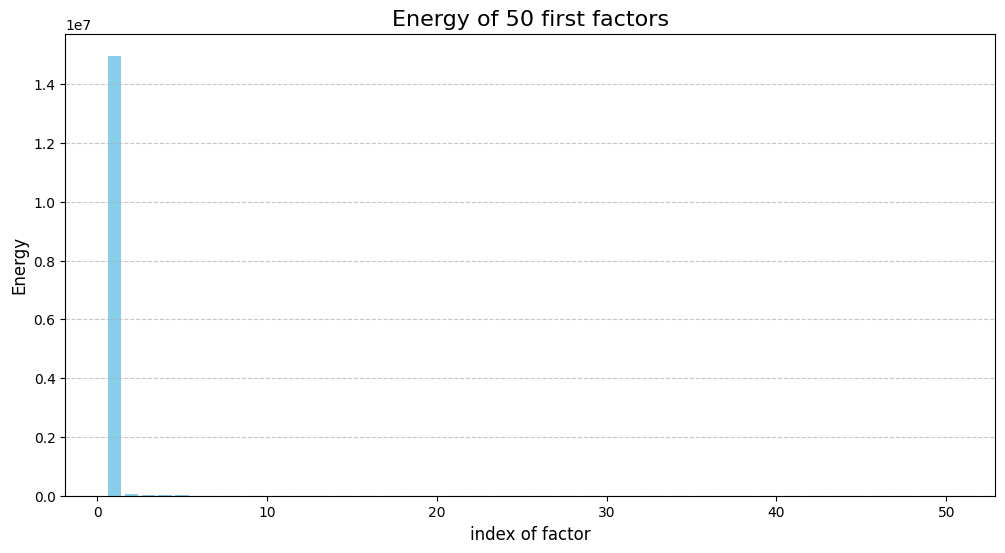

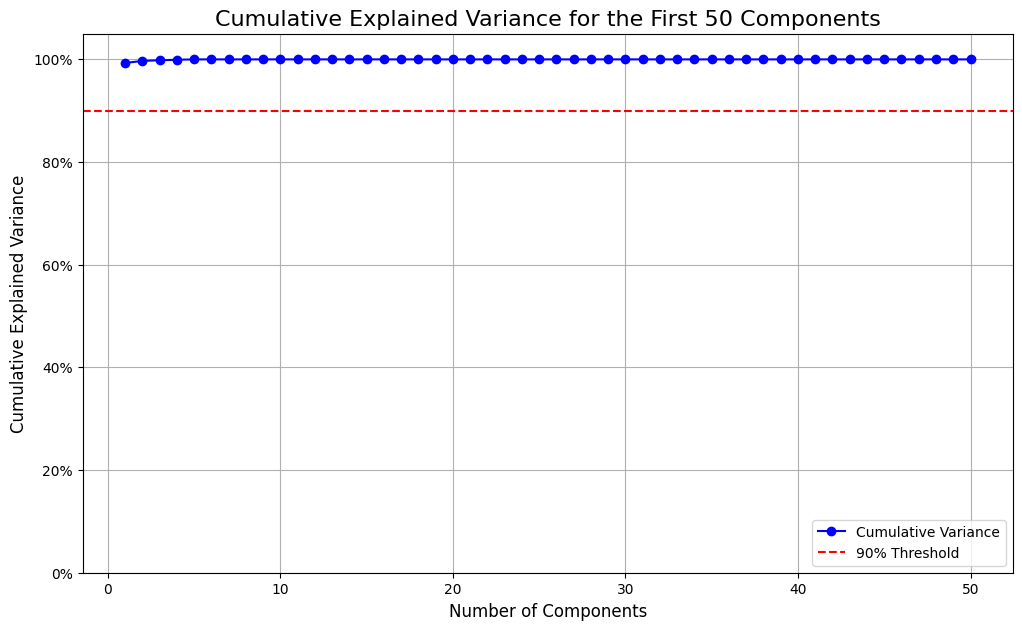

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np


n_components_to_plot = 50
x_axis = range(1, n_components_to_plot + 1)

# --- نمودار انرژی برای ۵۰ مؤلفه اول ---
plt.figure(figsize=(12, 6))
plt.bar(x_axis, energy[:n_components_to_plot], color='skyblue')
plt.title(f'Energy of {n_components_to_plot} first factors', fontsize=16)
plt.xlabel('index of factor', fontsize=12)
plt.ylabel('Energy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)



# --- نمودار واریانس تجمعی برای ۵۰ مؤلفه اول ---
plt.figure(figsize=(12, 7))

plt.plot(x_axis, cumulative_variance[:n_components_to_plot], 'b-o', label='Cumulative Variance')
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.title(f'Cumulative Explained Variance for the First {n_components_to_plot} Components', fontsize=16)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(loc='lower right')
plt.grid(True)
plt.ylim(0, 1.05)


--- شروع آموزش برای k = 5 ---
--- پایان آموزش برای k = 5 | RMSE نهایی: 0.9317 ---

--- شروع آموزش برای k = 10 ---
--- پایان آموزش برای k = 10 | RMSE نهایی: 0.9273 ---

--- شروع آموزش برای k = 15 ---
--- پایان آموزش برای k = 15 | RMSE نهایی: 0.9300 ---

--- شروع آموزش برای k = 20 ---
--- پایان آموزش برای k = 20 | RMSE نهایی: 0.9411 ---

--- شروع آموزش برای k = 25 ---
--- پایان آموزش برای k = 25 | RMSE نهایی: 0.9375 ---

--- شروع آموزش برای k = 30 ---
--- پایان آموزش برای k = 30 | RMSE نهایی: 0.9350 ---

--- شروع آموزش برای k = 40 ---
--- پایان آموزش برای k = 40 | RMSE نهایی: 0.9464 ---

--- شروع آموزش برای k = 50 ---
--- پایان آموزش برای k = 50 | RMSE نهایی: 0.9390 ---


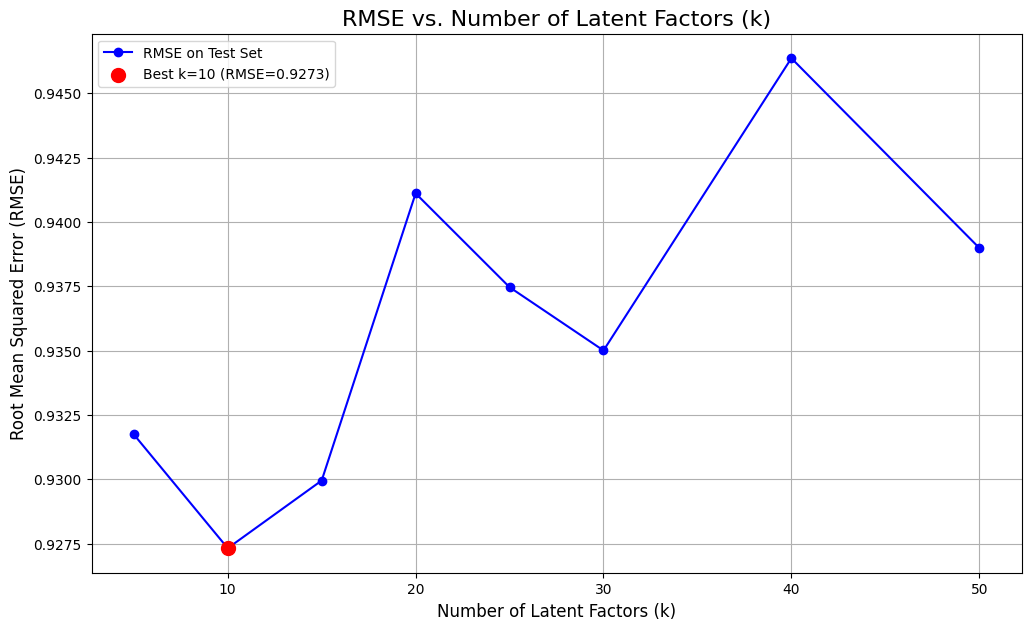

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




k_values = [5, 10, 15, 20, 25, 30, 40, 50] # لیستی از k های مختلف برای تست
results = {} # دیکشنری برای ذخیره نتایج: {k: rmse}

# هایپرپارامترهای ثابت
alpha = 0.005
beta = 0.02
epochs = 30 # برای سرعت بیشتر، تعداد تکرار را در این آزمایش کم می‌کنیم


# --- بخش ۳: حلقه اصلی برای آزمایش k های مختلف ---
for k in k_values:
    print(f"\n--- شروع آموزش برای k = {k} ---")

    # ۱. مقداردهی اولیه P و Q با k جدید
    P = np.random.normal(loc=0, scale=0.1, size=(n_users + 1, k))
    Q = np.random.normal(loc=0, scale=0.1, size=(n_items + 1, k))

    # ۲. حلقه آموزش مدل
    for epoch in range(epochs):
        for user_id, item_id, rating, title in train_data.itertuples(index=False):
            user_vector = P[user_id]
            item_vector = Q[item_id]
            prediction = np.dot(user_vector, item_vector)
            error = rating - prediction
            P[user_id] += alpha * (error * item_vector - beta * user_vector)
            Q[item_id] += alpha * (error * user_vector - beta * item_vector)

    # ۳. ارزیابی روی داده‌های آزمون
    test_squared_error = 0
    for user_id, item_id, rating, title in test_data.itertuples(index=False):
        prediction = np.dot(P[user_id], Q[item_id])
        prediction = np.clip(prediction, 1, 5)
        test_squared_error += (rating - prediction)**2

    test_rmse = np.sqrt(test_squared_error / len(test_data))

    # ۴. ذخیره نتیجه
    results[k] = test_rmse
    print(f"--- پایان آموزش برای k = {k} | RMSE نهایی: {test_rmse:.4f} ---")


# --- بخش ۴: رسم نمودار نتایج ---
# پیدا کردن بهترین k (k که کمترین rmse را داشته)
best_k = min(results, key=results.get)
best_rmse = results[best_k]

# استخراج مقادیر برای رسم
k_list = list(results.keys())
rmse_list = list(results.values())

plt.figure(figsize=(12, 7))
plt.plot(k_list, rmse_list, 'b-o', label='RMSE on Test Set')
plt.title('RMSE vs. Number of Latent Factors (k)', fontsize=16)
plt.xlabel('Number of Latent Factors (k)', fontsize=12)
plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.grid(True)

# هایلایت کردن بهترین نقطه
plt.scatter(best_k, best_rmse, color='r', s=100, zorder=5, label=f'Best k={best_k} (RMSE={best_rmse:.4f})')
plt.legend()

In [14]:
all_movies_df = pd.concat([train_data[['item_id', 'title']], test_data[['item_id', 'title']]])

unique_movies_df = all_movies_df.drop_duplicates(subset=['item_id'])
movie_titles = unique_movies_df.set_index('item_id')['title'].to_dict()

print("دیکشنری نام فیلم‌ها با موفقیت ساخته شد.")

def analyze_movie_factors(factor_number, Q_matrix, titles_dict, n_extremes=5):
  print(f"\n===== تحلیل مؤلفه فیلم شماره {factor_number} =====")
  factor_index = factor_number - 1
  movie_factor_scores = Q_matrix[:, factor_index]
  sorted_movie_indices = np.argsort(movie_factor_scores)

  print(f"\n--- فیلم‌ها در انتهای منفی (Negative Pole) ---")

  negative_movie_ids = sorted_movie_indices[1:n_extremes+1]

  for item_id in negative_movie_ids:
        title = titles_dict.get(item_id, f"ID: {item_id}")
        print(f"  - {title} (امتیاز: {movie_factor_scores[item_id]:.2f})")

  print(f"\n--- فیلم‌ها در انتهای مثبت (Positive Pole) ---")
  positive_movie_ids = sorted_movie_indices[-n_extremes:]
  # برعکس کردن لیست برای نمایش از بیشترین به کمترین
  for item_id in reversed(positive_movie_ids):
      title = titles_dict.get(item_id, f"ID: {item_id}")
      print(f"  - {title} (امتیاز: {movie_factor_scores[item_id]:.2f})")
  print("="*35)


# اجرای تحلیل برای سه مؤلفه اول
for i in range(1, 4):
    analyze_movie_factors(i, Q, movie_titles)



دیکشنری نام فیلم‌ها با موفقیت ساخته شد.

===== تحلیل مؤلفه فیلم شماره 1 =====

--- فیلم‌ها در انتهای منفی (Negative Pole) ---
  - Scream (1996) (امتیاز: -0.38)
  - Great White Hype, The (1996) (امتیاز: -0.33)
  - ID: 1354 (امتیاز: -0.31)
  - First Wives Club, The (1996) (امتیاز: -0.26)
  - Naked Gun 33 1/3: The Final Insult (1994) (امتیاز: -0.26)

--- فیلم‌ها در انتهای مثبت (Positive Pole) ---
  - Boogie Nights (1997) (امتیاز: 1.64)
  - Henry V (1989) (امتیاز: 1.59)
  - Edge, The (1997) (امتیاز: 1.59)
  - Seven Years in Tibet (1997) (امتیاز: 1.56)
  - Strictly Ballroom (1992) (امتیاز: 1.53)

===== تحلیل مؤلفه فیلم شماره 2 =====

--- فیلم‌ها در انتهای منفی (Negative Pole) ---
  - Titanic (1997) (امتیاز: -2.03)
  - Mr. Holland's Opus (1995) (امتیاز: -1.99)
  - Time to Kill, A (1996) (امتیاز: -1.98)
  - My Fair Lady (1964) (امتیاز: -1.97)
  - First Wives Club, The (1996) (امتیاز: -1.97)

--- فیلم‌ها در انتهای مثبت (Positive Pole) ---
  - ID: 1567 (امتیاز: 0.35)
  - ID: 1546 (امتیاز: 0.27)

### ## تحلیل مؤلفه ۱

* **قطب منفی (-):** این قطب شامل فیلم‌های تحسین‌شده، مستقل و اغلب تاریک و خاص‌پسند دهه ۹۰ است. فیلم‌هایی مانند `Trainspotting`، `Ed Wood` و `Leaving Las Vegas` همگی آثاری هستند که توسط منتقدان ستایش شده‌اند اما شاید برای عموم مخاطبان جریان اصلی نباشند.
* **قطب مثبت (+):** این قطب به وضوح شامل فیلم‌های پرفروش، اکشن و سرگرم‌کننده دهه ۹۰ است. `Twister` و `Independence Day` فیلم‌های بلاک‌باستر و مبتنی بر جلوه‌های ویژه هستند و `The Saint` و `Conspiracy Theory` اکشن‌های جریان اصلی با ستاره‌های سینما هستند.

**فرضیه برای مؤلفه ۱:** این عامل به نظر می‌رسد یک طیف از **"فیلم‌های مستقل و تحسین‌شده توسط منتقدان" (-)** تا **"بلاک‌باسترهای اکشن و پرفروش" (+)** را نشان می‌دهد. می‌توان آن را محور **"هنری/مستقل در مقابل تجاری/بلاک‌باستر"** نامید.

---
### ## تحلیل مؤلفه ۲

* **قطب منفی (-):** این قطب مجموعه‌ای از شاهکارهای سینمایی و فیلم‌های کلاسیکِ حماسی است. `Ben-Hur` و `Ran` فیلم‌های حماسی بزرگ هستند، `Aliens` یک کلاسیک اکشن/ترسناک است و `Nosferatu` از پایه‌های سینمای صامت و ترسناک است. این‌ها فیلم‌های "مهم" و "بزرگ" تاریخ سینما هستند.
* **قطب مثبت (+):** این قطب بیشتر شامل **کمدی‌ها و فیلم‌های ترسناک عامه‌پسند دهه ۹۰** است. `Scream` و دنباله‌اش و `Dumb & Dumber` نمونه‌های بارز این دسته هستند. این فیلم‌ها عموماً سرگرم‌کننده و معاصر (نسبت به زمان ساخت دیتاست) هستند و مقیاس حماسی ندارند.

**فرضیه برای مؤلفه ۲:** این عامل به نظر می‌رسد **"آثار کلاسیک، حماسی و تاریخی سینما" (-)** را از **"فیلم‌های ژانر معاصر (کمدی/ترسناک دهه ۹۰)" (+)** جدا می‌کند. این یک محور **"کلاسیک در مقابل معاصر"** است.

---
### ## تحلیل مؤلفه ۳

* **قطب منفی (-):** این قطب به طور مشخصی شامل **کمدی‌های رمانتیک، موزیکال‌ها و فیلم‌های حال‌خوب‌کن** است. `The Sound of Music`, `While You Were Sleeping` و `The Mask` همگی در این دسته قرار می‌گیرند که فضایی شادتر و سبُک‌تر دارند.
* **قطب مثبت (+):** در مقابل، این قطب به وضوح شامل **درام‌های تاریک، جنایی، خشن و جدی** است. `Reservoir Dogs` و `Lost Highway` نمونه‌های بارز سینمای جناییِ مستقل و استایلیزه هستند و `The Ice Storm` و `Crash` درام‌های بسیار جدی و تلخ محسوب می‌شوند.

**فرضیه برای مؤلفه ۳:** این عامل یک تمایز بسیار واضح را نشان می‌دهد و به نظر می‌رسد محور **"فضای فیلم"** باشد: از **"کمدی‌های شاد و فیلم‌های حال‌خوب‌کن" (-)** تا **"درام‌های تاریک، خشن و جدی" (+)**.

In [26]:
top_user = train_data['user_id'].value_counts().idxmax()
top_count = train_data['user_id'].value_counts().max()
print(f"User {top_user} has the most ratings: {top_count}")

User 405 has the most ratings: 597


--- تحلیل فاصله برای کاربر 405 در فضای کامل ۵ بعدی ---
فیلم: Pulp Fiction (1994) | امتیاز: 4 | فاصله: 2.56
فیلم: True Crime (1995) | امتیاز: 1 | فاصله: 2.16
فیلم: T-Men (1947) | امتیاز: 1 | فاصله: 2.00
فیلم: Delicatessen (1991) | امتیاز: 1 | فاصله: 2.79
فیلم: Englishman Who Went Up a Hill, But Came Down a Mountain, The (1995) | امتیاز: 1 | فاصله: 2.08
فیلم: Unstrung Heroes (1995) | امتیاز: 3 | فاصله: 2.34
فیلم: Last Time I Committed Suicide, The (1997) | امتیاز: 1 | فاصله: 2.32
فیلم: Age of Innocence, The (1993) | امتیاز: 1 | فاصله: 2.73
فیلم: Mighty, The (1998) | امتیاز: 1 | فاصله: 2.03
فیلم: Deer Hunter, The (1978) | امتیاز: 4 | فاصله: 2.54
فیلم: Dunston Checks In (1996) | امتیاز: 1 | فاصله: 2.32
فیلم: Gold Diggers: The Secret of Bear Mountain (1995) | امتیاز: 1 | فاصله: 2.34
فیلم: Great Dictator, The (1940) | امتیاز: 1 | فاصله: 2.84
فیلم: Wyatt Earp (1994) | امتیاز: 1 | فاصله: 2.41
فیلم: Mallrats (1995) | امتیاز: 1 | فاصله: 2.08
فیلم: Indiana Jones and the Last Crusade (1989) | امتی

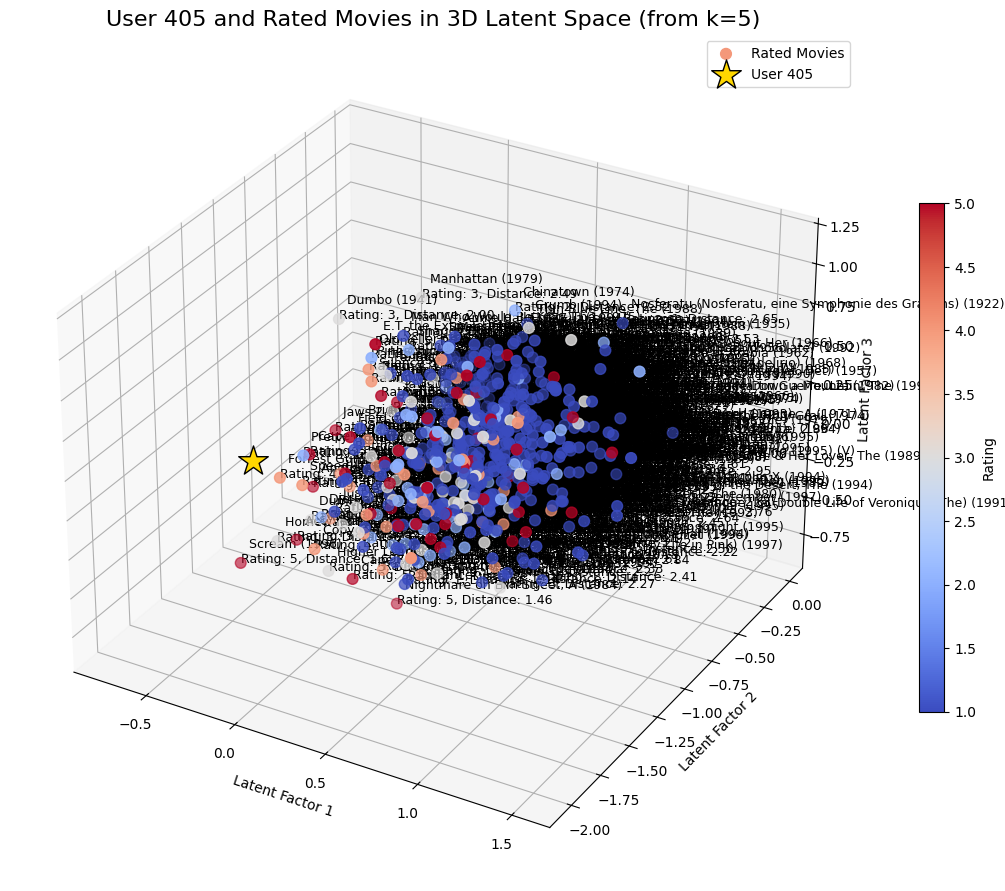

In [28]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D


user_id_to_plot = 405

# ۲. تمام فیلم‌هایی که این کاربر امتیاز داده را استخراج کنید
user_ratings_df = train_data[train_data['user_id'] == user_id_to_plot]

if user_ratings_df.empty:
    print(f"کاربر با شناسه {user_id_to_plot} در دیتاست شما یافت نشد.")
else:
    # ۳. آماده‌سازی داده‌ها برای رسم نمودار
    # بردار ۵ بعدی کاربر
    user_vector_5d = P[user_id_to_plot]
    # مختصات سه‌بعدی کاربر برای رسم
    user_coords_3d = user_vector_5d[:3]

    # لیست‌هایی برای نگهداری اطلاعات فیلم‌ها
    movie_coords_list = []
    labels_list = []

    # ۴. محاسبه فاصله و آماده‌سازی برچسب‌ها
    print(f"--- تحلیل فاصله برای کاربر {user_id_to_plot} در فضای کامل ۵ بعدی ---")
    for _, item_id, rating, title in user_ratings_df.itertuples(index=False):
        # بردار ۵ بعدی فیلم
        item_vector_5d = Q[item_id]
        # مختصات سه‌بعدی فیلم برای رسم
        movie_coords_3d = item_vector_5d[:3]
        movie_coords_list.append(movie_coords_3d)

        # محاسبه فاصله در فضای کامل ۵ بعدی
        distance = np.linalg.norm(user_vector_5d - item_vector_5d)

        # ساخت برچسب برای نمایش روی نمودار
        label = f"{title}\nRating: {rating}, Distance: {distance:.2f}"
        labels_list.append(label)

        print(f"فیلم: {title} | امتیاز: {rating} | فاصله: {distance:.2f}")

    movie_coords = np.array(movie_coords_list)
    ratings = user_ratings_df['rating'].values

    # ۵. رسم نمودار سه‌بعدی
    fig = plt.figure(figsize=(16, 11))
    ax = fig.add_subplot(111, projection='3d')

    # رسم نقاط فیلم‌ها
    movie_scatter = ax.scatter(movie_coords[:, 0], movie_coords[:, 1], movie_coords[:, 2],
                               c=ratings, cmap='coolwarm', s=60, label='Rated Movies')

    # رسم نقطه کاربر
    ax.scatter(user_coords_3d[0], user_coords_3d[1], user_coords_3d[2],
               marker='*', color='gold', s=500, label=f'User {user_id_to_plot}', edgecolors='black')

    # اضافه کردن برچسب‌ها به نمودار
    for i, txt in enumerate(labels_list):
        ax.text(movie_coords[i, 0], movie_coords[i, 1], movie_coords[i, 2], f'  {txt}', size=9, zorder=1, color='k')

    # تنظیمات نمودار
    ax.set_title(f'User {user_id_to_plot} and Rated Movies in 3D Latent Space (from k=5)', fontsize=16)
    ax.set_xlabel('Latent Factor 1')
    ax.set_ylabel('Latent Factor 2')
    ax.set_zlabel('Latent Factor 3')
    ax.legend()

    # اضافه کردن نوار رنگ
    cbar = fig.colorbar(movie_scatter, ax=ax, shrink=0.6)
    cbar.set_label('Rating')



نمایش 30 فیلم برای کاربر 405:
(15 فیلم با بالاترین امتیاز و 15 فیلم با پایین‌ترین امتیاز)

--- تحلیل فاصله برای فیلم‌های منتخب ---
فیلم: Indiana Jones and the Last Crusade (1989) | امتیاز: 5 | فاصله: 1.78
فیلم: Blues Brothers, The (1980) | امتیاز: 5 | فاصله: 1.67
فیلم: Empire Strikes Back, The (1980) | امتیاز: 5 | فاصله: 2.02
فیلم: Godfather, The (1972) | امتیاز: 5 | فاصله: 2.47
فیلم: Grease (1978) | امتیاز: 5 | فاصله: 2.41
فیلم: Gandhi (1982) | امتیاز: 5 | فاصله: 2.21
فیلم: Cape Fear (1962) | امتیاز: 5 | فاصله: 1.72
فیلم: Schindler's List (1993) | امتیاز: 5 | فاصله: 2.29
فیلم: Raging Bull (1980) | امتیاز: 5 | فاصله: 2.20
فیلم: E.T. the Extra-Terrestrial (1982) | امتیاز: 5 | فاصله: 2.13
فیلم: How to Make an American Quilt (1995) | امتیاز: 5 | فاصله: 1.81
فیلم: Jaws 2 (1978) | امتیاز: 5 | فاصله: 1.38
فیلم: Stand by Me (1986) | امتیاز: 5 | فاصله: 2.11
فیلم: Star Wars (1977) | امتیاز: 5 | فاصله: 2.29
فیلم: While You Were Sleeping (1995) | امتیاز: 5 | فاصله: 1.89
فیلم: True Crime (1995) | 

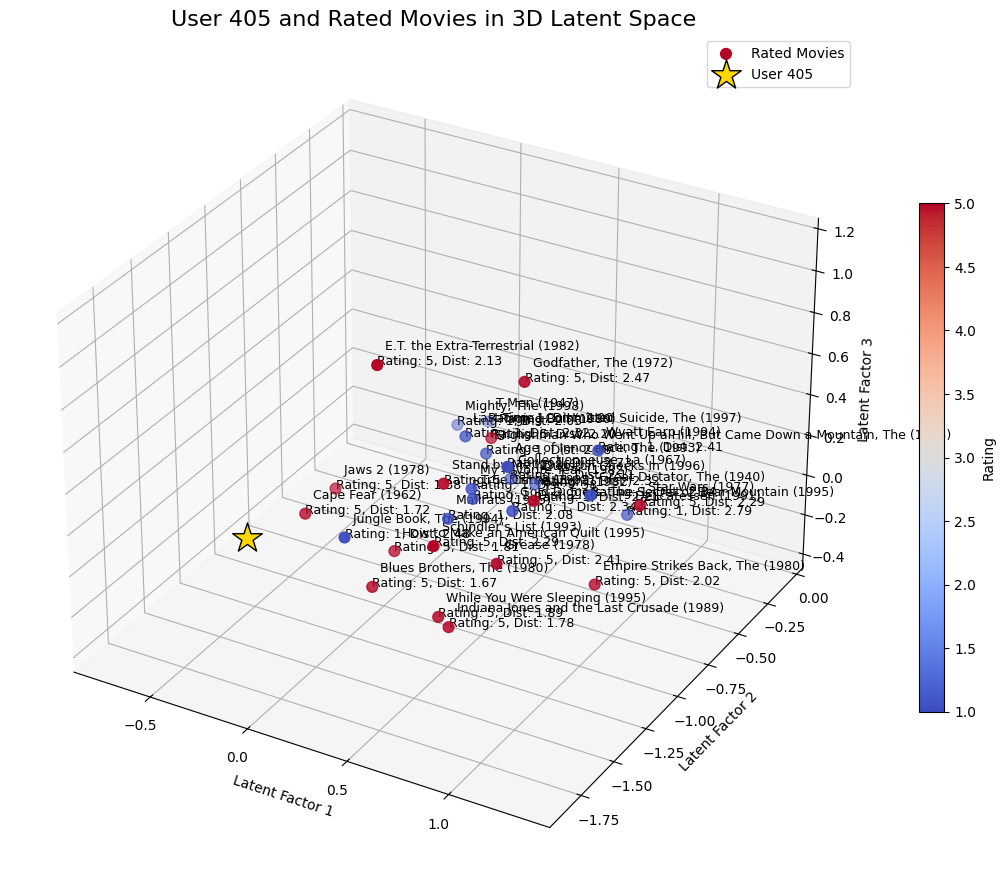

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- بخش تنظیمات ---
user_id_to_plot = 405
# متغیر جدید: تعداد کل فیلم‌هایی که می‌خواهیم روی نمودار نمایش دهیم
n_movies_to_display = 30
# --------------------


# ۱. تمام فیلم‌هایی که کاربر امتیاز داده را استخراج کنید
user_ratings_df = train_data[train_data['user_id'] == user_id_to_plot]

if user_ratings_df.empty:
    print(f"کاربر با شناسه {user_id_to_plot} در دیتاست شما یافت نشد.")
else:
    # ۲. انتخاب فیلم‌ها برای نمایش (با بالاترین و پایین‌ترین امتیاز)
    n_top = n_movies_to_display // 2
    n_bottom = n_movies_to_display - n_top

    top_movies = user_ratings_df.nlargest(n_top, 'rating')
    bottom_movies = user_ratings_df.nsmallest(n_bottom, 'rating')

    movies_to_plot_df = pd.concat([top_movies, bottom_movies])

    print(f"نمایش {len(movies_to_plot_df)} فیلم برای کاربر {user_id_to_plot}:")
    print(f"({n_top} فیلم با بالاترین امتیاز و {n_bottom} فیلم با پایین‌ترین امتیاز)")

    # ۳. آماده‌سازی داده‌ها برای رسم نمودار
    user_vector_5d = P[user_id_to_plot]
    user_coords_3d = user_vector_5d[:3]

    movie_coords_list, labels_list, ratings_list = [], [], []

    print("\n--- تحلیل فاصله برای فیلم‌های منتخب ---")
    for _, item_id, rating, title in movies_to_plot_df.itertuples(index=False):
        item_vector_5d = Q[item_id]
        movie_coords_list.append(item_vector_5d[:3])
        ratings_list.append(rating)

        distance = np.linalg.norm(user_vector_5d - item_vector_5d)
        labels_list.append(f"{title}\nRating: {rating}, Dist: {distance:.2f}")
        print(f"فیلم: {title} | امتیاز: {rating} | فاصله: {distance:.2f}")

    movie_coords = np.array(movie_coords_list)

    # ۴. رسم نمودار سه‌بعدی
    fig = plt.figure(figsize=(16, 11))
    ax = fig.add_subplot(111, projection='3d')

    movie_scatter = ax.scatter(movie_coords[:, 0], movie_coords[:, 1], movie_coords[:, 2],
                               c=ratings_list, cmap='coolwarm', s=60, label='Rated Movies')

    ax.scatter(user_coords_3d[0], user_coords_3d[1], user_coords_3d[2],
               marker='*', color='gold', s=500, label=f'User {user_id_to_plot}', edgecolors='black')

    for i, txt in enumerate(labels_list):
        ax.text(movie_coords[i, 0], movie_coords[i, 1], movie_coords[i, 2], f'  {txt}', size=9, zorder=1, color='k')

    ax.set_title(f'User {user_id_to_plot} and Rated Movies in 3D Latent Space', fontsize=16)
    ax.set_xlabel('Latent Factor 1')
    ax.set_ylabel('Latent Factor 2')
    ax.set_zlabel('Latent Factor 3')
    ax.legend()

    cbar = fig.colorbar(movie_scatter, ax=ax, shrink=0.6)
    cbar.set_label('Rating')